In [15]:
# --- Importações Essenciais ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

# --- Importações do Scikit-learn ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.feature_extraction import DictVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- Configurações de Visualização ---
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Bibliotecas importadas e configurações aplicadas.")

Bibliotecas importadas e configurações aplicadas.


In [16]:
# Carregar o dataset a partir do diretório de dados brutos
try:
    df = pd.read_csv('../../data/raw/cybersecurity_logs.csv')
    print("Dataset carregado com sucesso!")
    print(f"O dataset contém {df.shape} linhas e colunas.")
except FileNotFoundError:
    print("Erro: O arquivo 'cybersecurity_logs.csv' não foi encontrado.")
    print("Por favor, coloque o dataset no diretório 'data/raw/'.")

# Exibir as primeiras linhas e informações básicas para verificação
if 'df' in locals():
    print("\n--- Primeiras 5 linhas do dataset ---")
    print(df.head())
    print("\n--- Informações do DataFrame ---")
    df.info()

Erro: O arquivo 'cybersecurity_logs.csv' não foi encontrado.
Por favor, coloque o dataset no diretório 'data/raw/'.

--- Primeiras 5 linhas do dataset ---
            Timestamp     IP_Address Request_Type  Status_Code  Anomaly_Flag  \
0 2023-01-04 18:19:00  1.101.144.114         POST          403             0   
1 2023-01-04 20:11:00  1.108.146.246          PUT          403             0   
2 2023-01-06 22:32:00  1.110.138.224          PUT          500             0   
3 2023-01-03 06:01:00    1.114.13.16          PUT          200             0   
4 2023-01-04 12:56:00   1.114.241.24          PUT          500             0   

  User_Agent  Session_ID Location  hour  day_of_week  time_diff  \
0    Firefox        4986   France    18            2        0.0   
1        Bot        4067      USA    20            2        0.0   
2       Edge        3665    India    22            4        0.0   
3       Edge        3454      USA     6            1        0.0   
4    Firefox        1069  Ger


--- Análise Exploratória de Dados (EDA) ---

Valores ausentes por coluna:
Timestamp                 0
IP_Address                0
Request_Type              0
Status_Code               0
Anomaly_Flag              0
User_Agent                0
Session_ID                0
Location                  0
hour                      0
day_of_week               0
time_diff                 0
new_session_flag          0
session_id                0
session_id_global         0
event_in_session_count    0
dtype: int64

Distribuição da classe 'Anomaly_Flag':
Anomaly_Flag
0    0.951
1    0.049
Name: proportion, dtype: float64


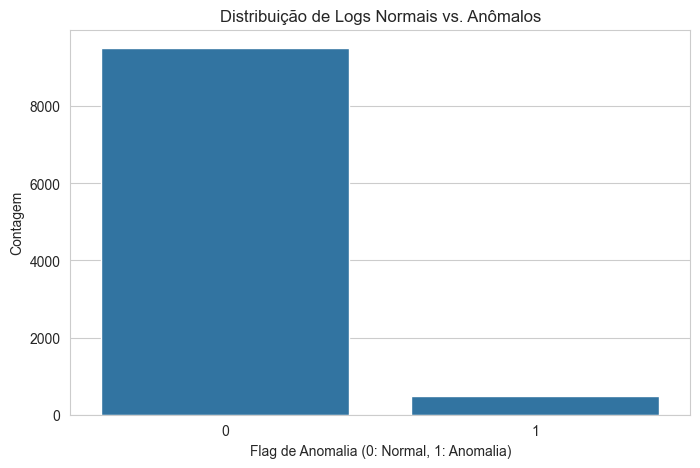

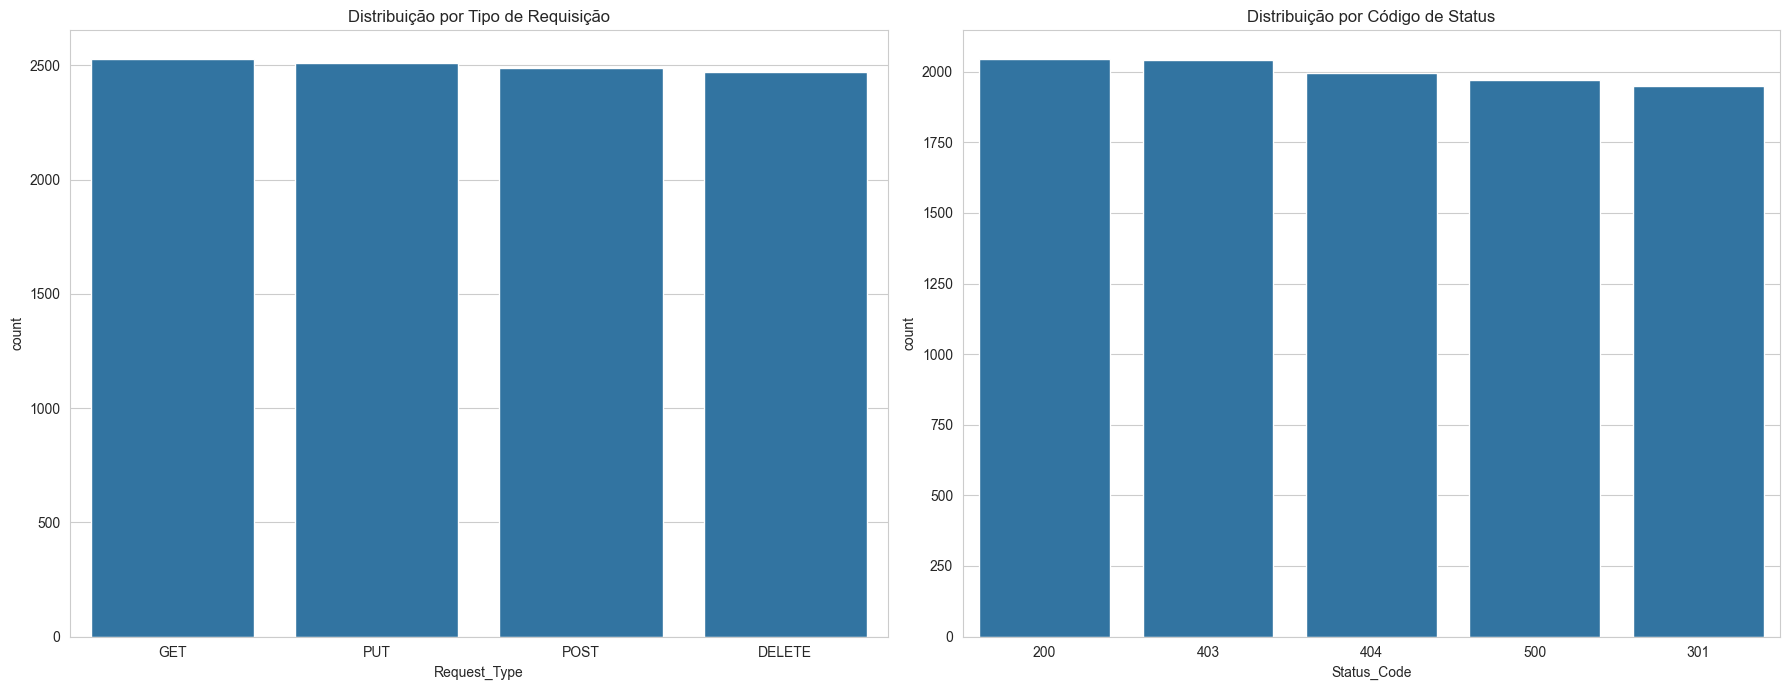

In [17]:
if 'df' in locals():
    print("\n--- Análise Exploratória de Dados (EDA) ---")

    # 1. Verificar valores ausentes
    print("\nValores ausentes por coluna:")
    print(df.isnull().sum())

    # 2. Analisar a variável alvo 'Anomaly_Flag'
    print("\nDistribuição da classe 'Anomaly_Flag':")
    print(df['Anomaly_Flag'].value_counts(normalize=True))
    
    plt.figure(figsize=(8, 5))
    sns.countplot(x='Anomaly_Flag', data=df)
    plt.title('Distribuição de Logs Normais vs. Anômalos')
    plt.xlabel('Flag de Anomalia (0: Normal, 1: Anomalia)')
    plt.ylabel('Contagem')
    plt.show()

    
    
    # 3. Definicao das ordens
    order_request = df['Request_Type'].value_counts().index.tolist()
    order_status = df['Status_Code'].value_counts().index.tolist()

    # 4. Analisar features categóricas importantes
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Gráfico para 'Request_Type'
    sns.countplot(ax=axes[0], x='Request_Type', data=df, order=order_request)
    axes[0].set_title('Distribuição por Tipo de Requisição')
    
    # Gráfico para 'Status_Code'
    
    sns.countplot(ax=axes[1], x='Status_Code', data=df, order=order_status)
    axes[1].set_title('Distribuição por Código de Status')

    plt.tight_layout()
    plt.show()

In [18]:
if 'df' in locals():
    print("\n--- Engenharia de Features ---")
    
    # Converter 'Timestamp' para datetime e ordenar
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df = df.sort_values(by=['IP_Address', 'Timestamp']).reset_index(drop=True)

    # Criar features temporais
    df['hour'] = df['Timestamp'].dt.hour
    df['day_of_week'] = df['Timestamp'].dt.dayofweek
    print("Features 'hour' e 'day_of_week' criadas.")

    # Diferença de tempo por IP e identificação de nova sessão
    df['time_diff'] = df.groupby('IP_Address')['Timestamp'].diff().dt.total_seconds().fillna(0)
    df['new_session_flag'] = (df['time_diff'] > 300).astype(int)
    df['session_id'] = df.groupby('IP_Address')['new_session_flag'].cumsum()

    # Criar um ID de sessão global
    df['session_id_global'] = df['IP_Address'].astype(str) + '_' + df['session_id'].astype(str)
    print("Features de sessão ('session_id_global') criadas.")

    # Contagem de eventos na sessão
    df['event_in_session_count'] = df.groupby('session_id_global').cumcount() + 1
    print("Feature 'event_in_session_count' criada.")

    print("\n--- DataFrame após engenharia de features ---")
    print(df.head())


--- Engenharia de Features ---
Features 'hour' e 'day_of_week' criadas.
Features de sessão ('session_id_global') criadas.
Feature 'event_in_session_count' criada.

--- DataFrame após engenharia de features ---
            Timestamp     IP_Address Request_Type  Status_Code  Anomaly_Flag  \
0 2023-01-04 18:19:00  1.101.144.114         POST          403             0   
1 2023-01-04 20:11:00  1.108.146.246          PUT          403             0   
2 2023-01-06 22:32:00  1.110.138.224          PUT          500             0   
3 2023-01-03 06:01:00    1.114.13.16          PUT          200             0   
4 2023-01-04 12:56:00   1.114.241.24          PUT          500             0   

  User_Agent  Session_ID Location  hour  day_of_week  time_diff  \
0    Firefox        4986   France    18            2        0.0   
1        Bot        4067      USA    20            2        0.0   
2       Edge        3665    India    22            4        0.0   
3       Edge        3454      USA     6 

In [19]:
if 'df' in locals():
    print("\n--- Divisão de Dados Baseada em Sessão ---")
    
    # Obter todos os IDs de sessão únicos
    all_session_ids = df['session_id_global'].unique()
    
    # Dividir os IDs de sessão em treino e teste
    train_session_ids, test_session_ids = train_test_split(all_session_ids, test_size=0.3, random_state=42)
    
    # Criar os DataFrames de treino e teste com base nos IDs de sessão
    train_df = df[df['session_id_global'].isin(train_session_ids)].copy()
    test_df = df[df['session_id_global'].isin(test_session_ids)].copy()
    
    # Separar features (X) e alvo (y)
    X_train = train_df.drop('Anomaly_Flag', axis=1)
    y_train = train_df['Anomaly_Flag']
    
    X_test = test_df.drop('Anomaly_Flag', axis=1)
    y_test = test_df['Anomaly_Flag']

    print(f"Total de sessões: {len(all_session_ids)}")
    print(f"Sessões de treino: {len(train_session_ids)}, Sessões de teste: {len(test_session_ids)}")
    print(f"Formato de X_train: {X_train.shape}, Formato de X_test: {X_test.shape}")


--- Divisão de Dados Baseada em Sessão ---
Total de sessões: 9998
Sessões de treino: 6998, Sessões de teste: 3000
Formato de X_train: (6999, 14), Formato de X_test: (3001, 14)


In [20]:
print("\n--- Definição do Pipeline de Pré-processamento ---")

# 1. Colunas por tipo
numeric_features = [
    'hour', 'day_of_week',
    'time_diff', 'event_in_session_count'
]
categorical_features_low = ['Request_Type', 'Status_Code', 'Location', 'User_Agent']
categorical_features_high = ['IP_Address']

# 2. Criar os pipelines de transformação
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer_low = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

def to_dicts(X_df):
    return X_df.to_dict(orient='records')

categorical_transformer_high = Pipeline(steps=[
    ('to_dicts', FunctionTransformer(to_dicts, validate=False)),
    ('dictvec', DictVectorizer(sparse=False))
])

# 3. Combinar com ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
    ('cat_low', categorical_transformer_low, categorical_features_low),
    ('cat_high', categorical_transformer_high, categorical_features_high)
], remainder='drop', verbose_feature_names_out=True)

print("Pipeline de pré-processamento criado com sucesso.")


--- Definição do Pipeline de Pré-processamento ---
Pipeline de pré-processamento criado com sucesso.


In [21]:
if 'preprocessor' in locals():
    print("\n--- Aplicando o Pré-processamento e Salvando os Artefatos ---")

    # 1. Treinar o pré-processador nos dados de treino e transformar ambos os conjuntos
    X_train_proc = preprocessor.fit_transform(X_train)
    X_test_proc = preprocessor.transform(X_test)

    print(f"Formato de X_train processado: {X_train_proc.shape}")
    print(f"Formato de X_test processado: {X_test_proc.shape}")

    # 2. Criar diretório para dados processados, se não existir
    processed_data_path = '../../data/processed/synthetic_dataset'
    os.makedirs(processed_data_path, exist_ok=True)
    print(f"\nDiretório '{processed_data_path}' pronto.")

    # 3. Salvar o pré-processador treinado (objeto)
    preprocessor_path = os.path.join(processed_data_path, 'preprocessor.pkl')
    joblib.dump(preprocessor, preprocessor_path)
    print(f"Pré-processador salvo em: {preprocessor_path}")

    # 4. Salvar os dados processados (arrays NumPy)
    # Nota: Salvar como.npz é eficiente para arrays NumPy
    train_proc_path = os.path.join(processed_data_path, 'train_processed.npz')
    test_proc_path = os.path.join(processed_data_path, 'test_processed.npz')
    
    np.savez_compressed(train_proc_path, X=X_train_proc, y=y_train.values)
    np.savez_compressed(test_proc_path, X=X_test_proc, y=y_test.values)
    
    print(f"Dados de treino processados salvos em: {train_proc_path}")
    print(f"Dados de teste processados salvos em: {test_proc_path}")


--- Aplicando o Pré-processamento e Salvando os Artefatos ---
Formato de X_train processado: (6999, 6992)
Formato de X_test processado: (3001, 6992)

Diretório '../../data/processed/synthetic_dataset' pronto.
Pré-processador salvo em: ../../data/processed/synthetic_dataset\preprocessor.pkl
Dados de treino processados salvos em: ../../data/processed/synthetic_dataset\train_processed.npz
Dados de teste processados salvos em: ../../data/processed/synthetic_dataset\test_processed.npz
